# Pipeline de predicción de rotación de empleados

**Autor:** Jeshua Romero Guadarrama

**Conjunto de datos:** [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) (dataset real publicado por IBM para el análisis de rotación laboral).

**Objetivo:** Construir un pipeline de clasificación completo que prediga si un empleado abandonará la empresa (`Attrition`), utilizando 35 características laborales, demográficas y de satisfacción. El pipeline integra limpieza de datos, ingeniería de características, preprocesamiento diferenciado, selección de modelos mediante `GridSearchCV` con validación cruzada estratificada, y exportación del modelo final a `.pkl`.

**Relevancia del problema:** La rotación de personal tiene un costo estimado de entre el 50% y el 200% del salario anual del empleado; por lo tanto, predecir qué empleados tienen mayor riesgo de abandonar la empresa permite a recursos humanos implementar estrategias de retención preventivas.

**Características del dataset:**
- Un total de 1,470 empleados con 35 variables.
- Variables numéricas (edad, ingreso mensual, distancia al trabajo, años en la empresa, entre otras).
- Variables categóricas (departamento, rol, estado civil, nivel educativo, entre otras).
- Variable objetivo llamada `Attrition` (Yes/No), aunque resulta **desbalanceada** (83.9% No, 16.1% Sí)

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

## 2. Carga del conjunto de datos

In [2]:
# Cargar el dataset desde el repositorio oficial de IBM en GitHub
url_dataset = 'https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv'
df = pd.read_csv(url_dataset)

# Guardar copia local
df.to_csv('empleados_rotacion.csv', index = False)

print(f"Dataset cargado: {df.shape[0]} empleados, {df.shape[1]} variables")
print(f"Fuente: IBM HR Analytics (repositorio oficial de IBM en GitHub)")
df.head()

Dataset cargado: 1470 empleados, 35 variables
Fuente: IBM HR Analytics (repositorio oficial de IBM en GitHub)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Análisis exploratorio de datos

In [3]:
# Información general
print("Tipos de datos y valores faltantes:")
print(f"{'Columna':<30} {'Tipo':<12} {'Nulos':<8} {'Únicos':<8}")
print("-" * 58)
for col in df.columns:
    print(f"{col:<30} {str(df[col].dtype):<12} {df[col].isnull().sum():<8} {df[col].nunique():<8}")

print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")

Tipos de datos y valores faltantes:
Columna                        Tipo         Nulos    Únicos  
----------------------------------------------------------
Age                            int64        0        43      
Attrition                      object       0        2       
BusinessTravel                 object       0        3       
DailyRate                      int64        0        886     
Department                     object       0        3       
DistanceFromHome               int64        0        29      
Education                      int64        0        5       
EducationField                 object       0        6       
EmployeeCount                  int64        0        1       
EmployeeNumber                 int64        0        1470    
EnvironmentSatisfaction        int64        0        4       
Gender                         object       0        2       
HourlyRate                     int64        0        71      
JobInvolvement                 int64 

Distribución de la variable objetivo (Attrition):
  No abandonó (No):  1,233 (83.9%)
  Abandonó (Yes):    237 (16.1%)


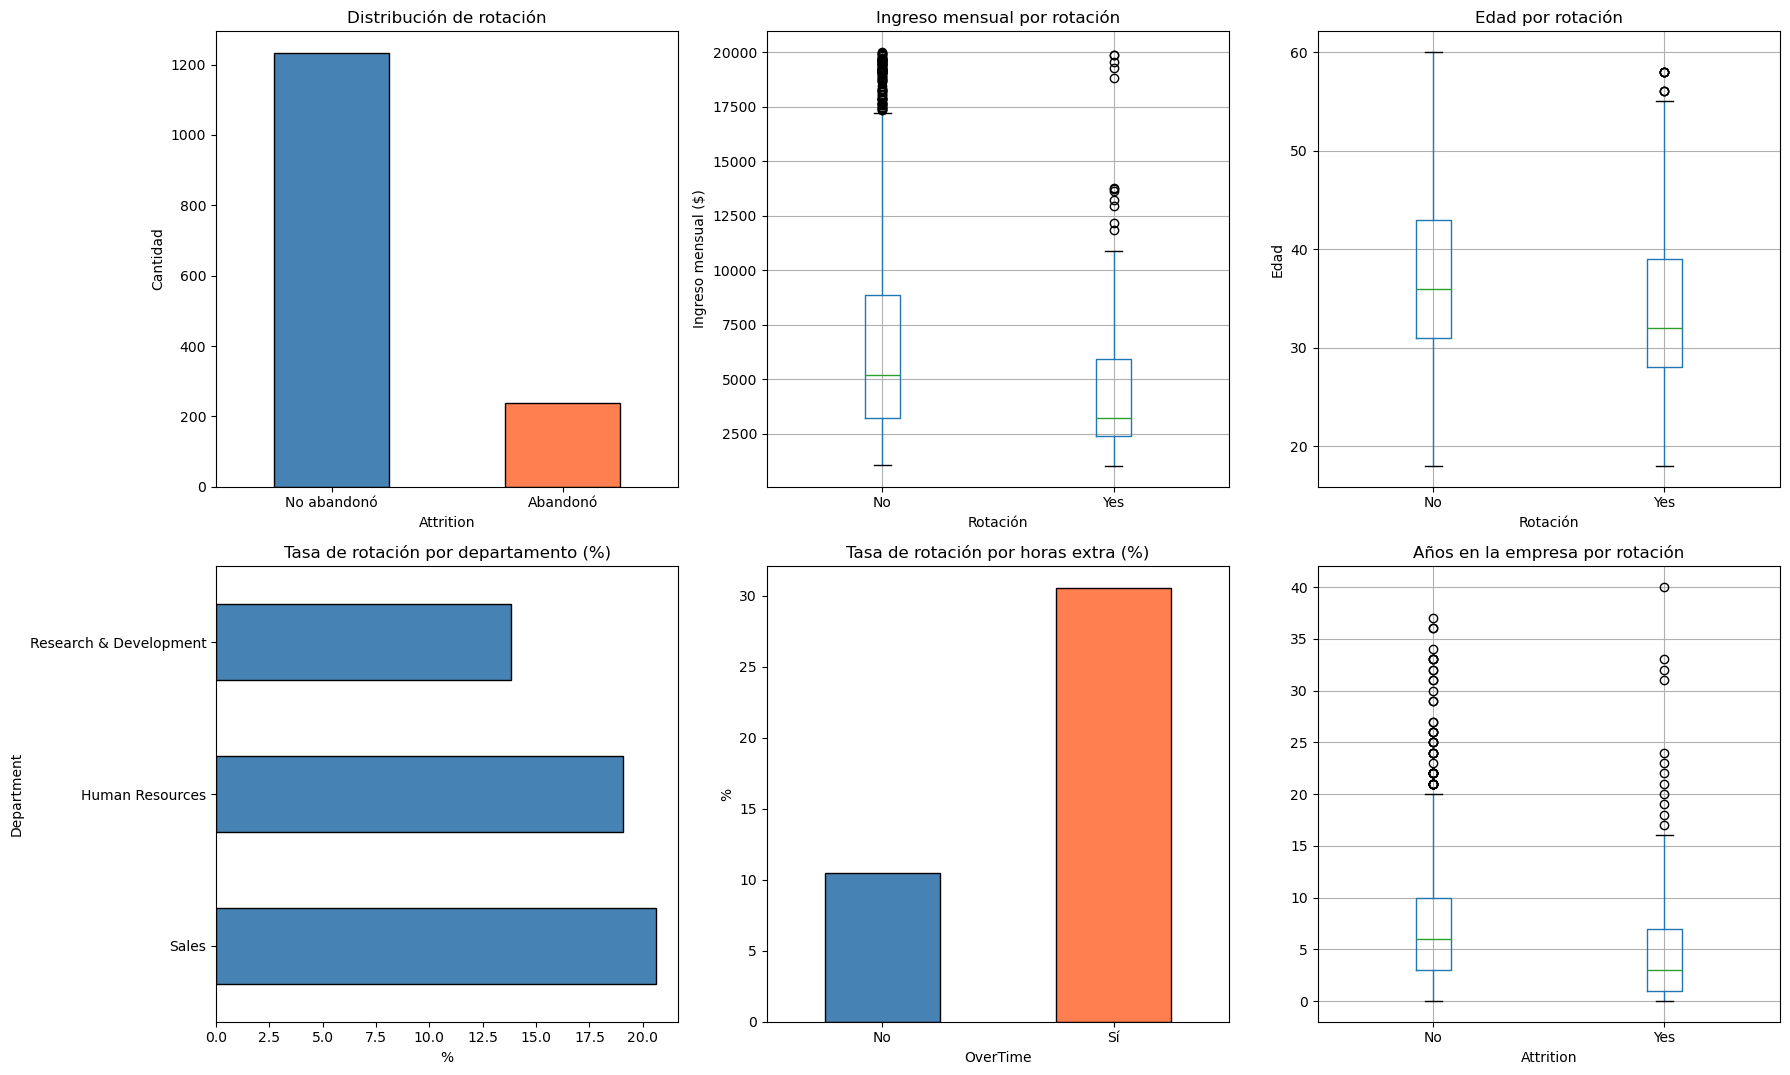

In [4]:
# Distribución de la variable objetivo
conteo_rotacion = df['Attrition'].value_counts()
print("Distribución de la variable objetivo (Attrition):")
print(f"  No abandonó (No):  {conteo_rotacion['No']:,} ({conteo_rotacion['No']/len(df)*100:.1f}%)")
print(f"  Abandonó (Yes):    {conteo_rotacion['Yes']:,} ({conteo_rotacion['Yes']/len(df)*100:.1f}%)")

figura, ejes = plt.subplots(2, 3, figsize = (18, 11))

# Distribución del target
conteo_rotacion.plot(kind = 'bar', ax = ejes[0][0], color = ['steelblue', 'coral'], edgecolor = 'black')
ejes[0][0].set_title('Distribución de rotación')
ejes[0][0].set_xticklabels(['No abandonó', 'Abandonó'], rotation = 0)
ejes[0][0].set_ylabel('Cantidad')

# Ingreso mensual por rotación
df.boxplot(column = 'MonthlyIncome', by = 'Attrition', ax = ejes[0][1])
ejes[0][1].set_title('Ingreso mensual por rotación')
ejes[0][1].set_xlabel('Rotación')
ejes[0][1].set_ylabel('Ingreso mensual ($)')
plt.sca(ejes[0][1])
plt.title('Ingreso mensual por rotación')

# Edad por rotación
df.boxplot(column = 'Age', by = 'Attrition', ax = ejes[0][2])
ejes[0][2].set_title('Edad por rotación')
ejes[0][2].set_xlabel('Rotación')
ejes[0][2].set_ylabel('Edad')
plt.sca(ejes[0][2])
plt.title('Edad por rotación')

# Rotación por departamento
tasa_depto = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
tasa_depto.sort_values(ascending = False).plot(kind = 'barh', ax = ejes[1][0], color = 'steelblue', edgecolor = 'black')
ejes[1][0].set_title('Tasa de rotación por departamento (%)')
ejes[1][0].set_xlabel('%')

# Rotación por horas extra
tasa_overtime = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
tasa_overtime.plot(kind = 'bar', ax = ejes[1][1], color = ['steelblue', 'coral'], edgecolor = 'black')
ejes[1][1].set_title('Tasa de rotación por horas extra (%)')
ejes[1][1].set_xticklabels(['No', 'Sí'], rotation = 0)
ejes[1][1].set_ylabel('%')

# Años en la empresa por rotación
df.boxplot(column = 'YearsAtCompany', by = 'Attrition', ax = ejes[1][2])
ejes[1][2].set_title('Años en la empresa por rotación')
plt.sca(ejes[1][2])
plt.title('Años en la empresa por rotación')

plt.suptitle('')
plt.tight_layout()
plt.show()

Del análisis exploratorio identifico patrones claros:

- Los empleados que abandonan tienen un **ingreso mensual significativamente menor**.
- Los empleados **más jóvenes** presentan mayor tasa de rotación.
- Las **horas extra** son un factor determinante, ya que los empleados con overtime tienen una tasa de rotación mucho más alta.
- Los empleados con **menos años en la empresa** son más propensos a abandonar.

## 4. Limpieza e ingeniería de características

In [5]:
# Eliminar columnas sin varianza o no informativas
columnas_eliminar = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_limpio         = df.drop(columns = columnas_eliminar)
print(f"Columnas eliminadas (sin varianza): {columnas_eliminar}")

# Codificar la variable objetivo a binario
df_limpio['Attrition'] = (df_limpio['Attrition'] == 'Yes').astype(int)

# Ingeniería de características
df_limpio['ingreso_por_anio_experiencia'] = df_limpio['MonthlyIncome'] / (df_limpio['TotalWorkingYears'] + 1)
df_limpio['ratio_anios_empresa_total']    = df_limpio['YearsAtCompany'] / (df_limpio['TotalWorkingYears'] + 1)
df_limpio['anios_sin_promocion_ratio']    = df_limpio['YearsSinceLastPromotion'] / (df_limpio['YearsAtCompany'] + 1)
df_limpio['satisfaccion_promedio']        = (
    df_limpio['EnvironmentSatisfaction'] +
    df_limpio['JobSatisfaction'] +
    df_limpio['RelationshipSatisfaction'] +
    df_limpio['WorkLifeBalance']
) / 4

print(f"\nVariables de ingeniería creadas:")
print(f"  - ingreso_por_anio_experiencia: Ingreso mensual / Años de experiencia")
print(f"  - ratio_anios_empresa_total: Proporción de carrera en esta empresa")
print(f"  - anios_sin_promocion_ratio: Proporción de tiempo sin promoción")
print(f"  - satisfaccion_promedio: Promedio de las 4 métricas de satisfacción")
print(f"\nDataset final: {df_limpio.shape[0]} filas, {df_limpio.shape[1]} columnas")

Columnas eliminadas (sin varianza): ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

Variables de ingeniería creadas:
  - ingreso_por_anio_experiencia: Ingreso mensual / Años de experiencia
  - ratio_anios_empresa_total: Proporción de carrera en esta empresa
  - anios_sin_promocion_ratio: Proporción de tiempo sin promoción
  - satisfaccion_promedio: Promedio de las 4 métricas de satisfacción

Dataset final: 1470 filas, 35 columnas


En este punto, creé cuatro variables derivadas que capturan relaciones no evidentes en los datos crudos. Las variables aportan contexto proporcional que los modelos no pueden inferir directamente de las variables individuales.

## 5. Definición del pipeline de preprocesamiento

In [6]:
# Separar variables predictoras y objetivo
X = df_limpio.drop('Attrition', axis = 1)
y = df_limpio['Attrition']

# Identificar columnas numéricas y categóricas automáticamente
columnas_numericas   = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()
columnas_categoricas = X.select_dtypes(include = ['object']).columns.tolist()

print(f"Variables numéricas ({len(columnas_numericas)}):")
for col in columnas_numericas:
    print(f"  - {col}")
print(f"\nVariables categóricas ({len(columnas_categoricas)}):")
for col in columnas_categoricas:
    print(f"  - {col} ({df_limpio[col].nunique()} categorías)")

# Pipeline para numéricas: imputación por mediana + escalado estándar
preprocesador_numerico = Pipeline(steps = [
    ('imputador', SimpleImputer(strategy = 'median')),
    ('escalador', StandardScaler()),
])

# Pipeline para categóricas: imputación por moda + codificación One-Hot
preprocesador_categorico = Pipeline(steps = [
    ('imputador',    SimpleImputer(strategy = 'most_frequent')),
    ('codificador',  OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)),
])

# ColumnTransformer que combina ambos preprocesadores
preprocesador = ColumnTransformer(transformers = [
    ('numericas',   preprocesador_numerico,   columnas_numericas),
    ('categoricas', preprocesador_categorico, columnas_categoricas),
])

print("\nPipeline de preprocesamiento definido correctamente.")

Variables numéricas (27):
  - Age
  - DailyRate
  - DistanceFromHome
  - Education
  - EnvironmentSatisfaction
  - HourlyRate
  - JobInvolvement
  - JobLevel
  - JobSatisfaction
  - MonthlyIncome
  - MonthlyRate
  - NumCompaniesWorked
  - PercentSalaryHike
  - PerformanceRating
  - RelationshipSatisfaction
  - StockOptionLevel
  - TotalWorkingYears
  - TrainingTimesLastYear
  - WorkLifeBalance
  - YearsAtCompany
  - YearsInCurrentRole
  - YearsSinceLastPromotion
  - YearsWithCurrManager
  - ingreso_por_anio_experiencia
  - ratio_anios_empresa_total
  - anios_sin_promocion_ratio
  - satisfaccion_promedio

Variables categóricas (7):
  - BusinessTravel (3 categorías)
  - Department (3 categorías)
  - EducationField (6 categorías)
  - Gender (2 categorías)
  - JobRole (9 categorías)
  - MaritalStatus (3 categorías)
  - OverTime (2 categorías)

Pipeline de preprocesamiento definido correctamente.


## 6. División del dataset

In [7]:
# División estratificada: 80% entrenamiento, 20% prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y,
)

print(f"Conjunto de entrenamiento: {X_entrenamiento.shape[0]} empleados")
print(f"Conjunto de prueba:        {X_prueba.shape[0]} empleados")
print(f"\nProporción de rotación en entrenamiento: {y_entrenamiento.mean():.2%}")
print(f"Proporción de rotación en prueba:         {y_prueba.mean():.2%}")

Conjunto de entrenamiento: 1176 empleados
Conjunto de prueba:        294 empleados

Proporción de rotación en entrenamiento: 16.16%
Proporción de rotación en prueba:         15.99%


## 7. Selección de modelos mediante GridSearchCV

A continuación, evalúo cuatro algoritmos de clasificación con búsqueda exhaustiva de hiperparámetros. Así pues, utilizo validación cruzada estratificada de cinco pliegues y optimizo por **F1-Score**, ya que el dataset está desbalanceado y necesito equilibrar precisión y recall.

In [8]:
# Definir modelos candidatos con sus hiperparámetros
modelos_candidatos = {
    'Regresión Logística': {
        'pipeline': Pipeline([
            ('preprocesador', preprocesador),
            ('clasificador',  LogisticRegression(
                max_iter     = 2000,
                random_state = 42,
                class_weight = 'balanced',
            )),
        ]),
        'parametros': {
            'clasificador__C':       [0.01, 0.1, 1, 10],
            'clasificador__penalty': ['l2'],
        },
    },
    'Bosque Aleatorio': {
        'pipeline': Pipeline([
            ('preprocesador', preprocesador),
            ('clasificador',  RandomForestClassifier(
                random_state = 42,
                class_weight = 'balanced',
            )),
        ]),
        'parametros': {
            'clasificador__n_estimators':    [100, 200],
            'clasificador__max_depth':       [5, 10, 15],
            'clasificador__min_samples_split': [5, 10],
        },
    },
    'Gradient Boosting': {
        'pipeline': Pipeline([
            ('preprocesador', preprocesador),
            ('clasificador',  GradientBoostingClassifier(random_state = 42)),
        ]),
        'parametros': {
            'clasificador__n_estimators':  [100, 200],
            'clasificador__max_depth':     [3, 5],
            'clasificador__learning_rate': [0.05, 0.1, 0.2],
        },
    },
    'SVM': {
        'pipeline': Pipeline([
            ('preprocesador', preprocesador),
            ('clasificador',  SVC(
                random_state = 42,
                probability  = True,
                class_weight = 'balanced',
            )),
        ]),
        'parametros': {
            'clasificador__C':      [0.1, 1, 10],
            'clasificador__kernel': ['rbf', 'linear'],
        },
    },
}

print(f"Modelos candidatos: {len(modelos_candidatos)}")
total_combinaciones = 0
for nombre, config in modelos_candidatos.items():
    n = 1
    for v in config['parametros'].values():
        n *= len(v)
    total_combinaciones += n
    print(f"  - {nombre}: {n} combinaciones")
print(f"\nTotal de combinaciones a evaluar: {total_combinaciones}")
print(f"Total de ajustes (x5 pliegues): {total_combinaciones * 5}")

Modelos candidatos: 4
  - Regresión Logística: 4 combinaciones
  - Bosque Aleatorio: 12 combinaciones
  - Gradient Boosting: 12 combinaciones
  - SVM: 6 combinaciones

Total de combinaciones a evaluar: 34
Total de ajustes (x5 pliegues): 170


In [9]:
# Ejecutar GridSearchCV para cada modelo
validacion_cruzada = StratifiedKFold(
    n_splits     = 5,
    shuffle      = True,
    random_state = 42,
)

resultados_modelos   = {}
mejor_puntaje_global = 0
mejor_modelo_nombre  = ''
mejor_modelo_objeto  = None

print("Ejecutando GridSearchCV con validación cruzada estratificada (cinco pliegues)...")
print(f"Métrica de optimización: F1-Score\n")
print(f"{'Modelo':<25} {'Mejor F1-CV':<15} {'Mejores hiperparámetros'}")
print("-" * 90)

for nombre, config in modelos_candidatos.items():
    busqueda = GridSearchCV(
        estimator  = config['pipeline'],
        param_grid = config['parametros'],
        cv         = validacion_cruzada,
        scoring    = 'f1',
        n_jobs     = -1,
        refit      = True,
    )
    busqueda.fit(X_entrenamiento, y_entrenamiento)

    resultados_modelos[nombre] = {
        'mejor_puntaje':      busqueda.best_score_,
        'mejores_parametros': busqueda.best_params_,
        'mejor_estimador':    busqueda.best_estimator_,
    }

    params_cortos = {k.replace('clasificador__', ''): v for k, v in busqueda.best_params_.items()}
    print(f"{nombre:<25} {busqueda.best_score_:<15.4f} {params_cortos}")

    if busqueda.best_score_ > mejor_puntaje_global:
        mejor_puntaje_global = busqueda.best_score_
        mejor_modelo_nombre  = nombre
        mejor_modelo_objeto  = busqueda.best_estimator_

print(f"\nMejor modelo seleccionado: {mejor_modelo_nombre} (F1-CV = {mejor_puntaje_global:.4f})")

Ejecutando GridSearchCV con validación cruzada estratificada (cinco pliegues)...
Métrica de optimización: F1-Score

Modelo                    Mejor F1-CV     Mejores hiperparámetros
------------------------------------------------------------------------------------------


Regresión Logística       0.5080          {'C': 0.01, 'penalty': 'l2'}


Bosque Aleatorio          0.4676          {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


Gradient Boosting         0.4597          {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


SVM                       0.5318          {'C': 1, 'kernel': 'rbf'}

Mejor modelo seleccionado: SVM (F1-CV = 0.5318)


## 8. Validación cruzada detallada del mejor modelo

In [10]:
# Validación cruzada con múltiples métricas
metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print(f"Validación cruzada detallada: {mejor_modelo_nombre}\n")
print(f"{'Métrica':<20} {'Media':<12} {'Desv. Est.':<12} {'Mín':<12} {'Máx':<12}")
print("-" * 68)

for metrica in metricas_cv:
    puntajes = cross_val_score(
        mejor_modelo_objeto, X_entrenamiento, y_entrenamiento,
        cv      = validacion_cruzada,
        scoring = metrica,
    )
    print(f"{metrica:<20} {puntajes.mean():<12.4f} {puntajes.std():<12.4f} {puntajes.min():<12.4f} {puntajes.max():<12.4f}")

Validación cruzada detallada: SVM

Métrica              Media        Desv. Est.   Mín          Máx         
--------------------------------------------------------------------


accuracy             0.8316       0.0135       0.8128       0.8475      


precision            0.4836       0.0330       0.4400       0.5250      


recall               0.5947       0.0718       0.5000       0.7105      


f1                   0.5318       0.0408       0.4810       0.6000      


roc_auc              0.8163       0.0373       0.7740       0.8674      


Los resultados de la validación cruzada muestran un modelo con rendimiento estable entre pliegues (baja desviación estándar), lo que indica buena capacidad de generalización.

## 9. Evaluación final sobre el conjunto de prueba

In [11]:
# Predicciones sobre el conjunto de prueba
predicciones   = mejor_modelo_objeto.predict(X_prueba)
probabilidades = mejor_modelo_objeto.predict_proba(X_prueba)[:, 1]

# Métricas
exactitud = accuracy_score(y_prueba, predicciones)
precision = precision_score(y_prueba, predicciones)
recall    = recall_score(y_prueba, predicciones)
f1        = f1_score(y_prueba, predicciones)
auc_roc   = roc_auc_score(y_prueba, probabilidades)

print("=" * 60)
print(f"EVALUACIÓN FINAL DEL MODELO — {mejor_modelo_nombre.upper()}")
print("=" * 60)
print(f"\n  Exactitud (Accuracy):   {exactitud:.4f}")
print(f"  Precisión (Precision):  {precision:.4f}")
print(f"  Recall (Sensibilidad):  {recall:.4f}")
print(f"  F1-Score:               {f1:.4f}")
print(f"  AUC-ROC:                {auc_roc:.4f}")
print(f"\n{'=' * 60}")

print("\nReporte de clasificación completo:")
print(classification_report(
    y_prueba,
    predicciones,
    target_names = ['No abandonó', 'Abandonó'],
))

EVALUACIÓN FINAL DEL MODELO — SVM

  Exactitud (Accuracy):   0.8197
  Precisión (Precision):  0.4483
  Recall (Sensibilidad):  0.5532
  F1-Score:               0.4952
  AUC-ROC:                0.8024


Reporte de clasificación completo:
              precision    recall  f1-score   support

 No abandonó       0.91      0.87      0.89       247
    Abandonó       0.45      0.55      0.50        47

    accuracy                           0.82       294
   macro avg       0.68      0.71      0.69       294
weighted avg       0.84      0.82      0.83       294



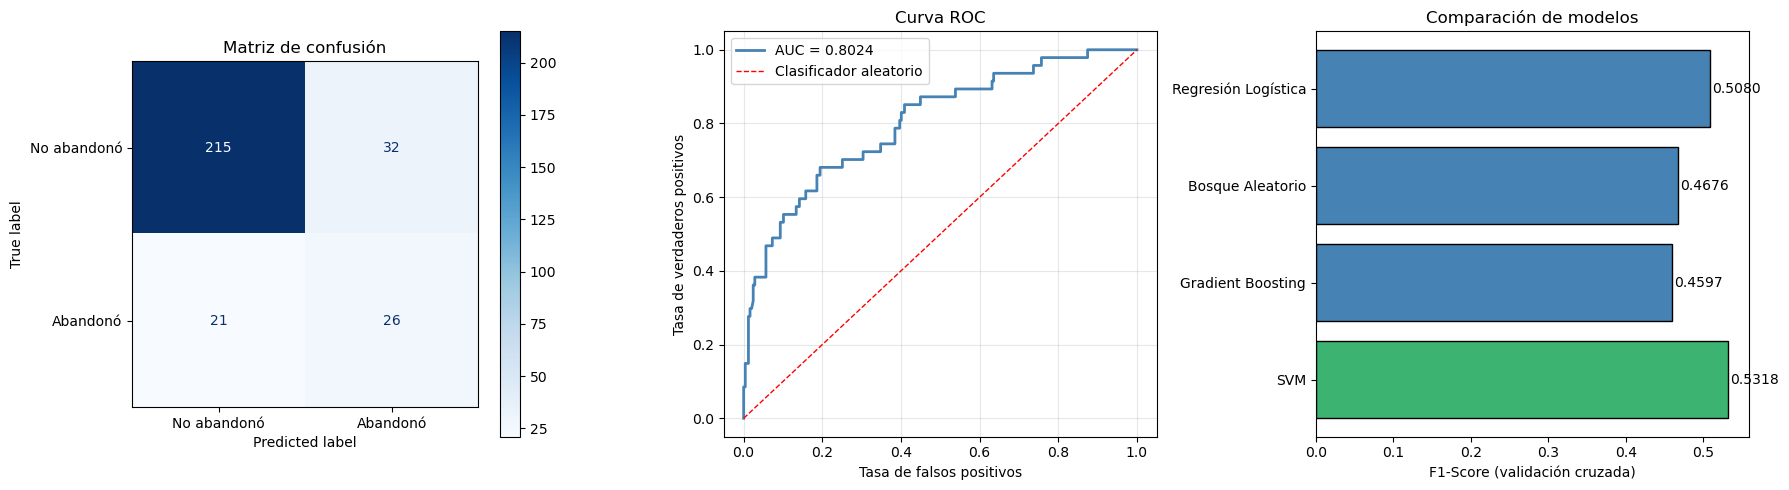

In [12]:
# Visualizaciones de evaluación
figura, ejes = plt.subplots(1, 3, figsize = (18, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_prueba, predicciones,
    display_labels = ['No abandonó', 'Abandonó'],
    cmap           = 'Blues',
    ax             = ejes[0],
)
ejes[0].set_title('Matriz de confusión')

# Curva ROC
fpr, tpr, _ = roc_curve(y_prueba, probabilidades)
ejes[1].plot(fpr, tpr, color = 'steelblue', linewidth = 2, label = f'AUC = {auc_roc:.4f}')
ejes[1].plot([0, 1], [0, 1], 'r--', linewidth = 1, label = 'Clasificador aleatorio')
ejes[1].set_xlabel('Tasa de falsos positivos')
ejes[1].set_ylabel('Tasa de verdaderos positivos')
ejes[1].set_title('Curva ROC')
ejes[1].legend()
ejes[1].grid(True, alpha = 0.3)

# Comparación de modelos
nombres_modelos  = list(resultados_modelos.keys())
puntajes_modelos = [resultados_modelos[n]['mejor_puntaje'] for n in nombres_modelos]
colores_barras   = ['mediumseagreen' if n == mejor_modelo_nombre else 'steelblue' for n in nombres_modelos]

ejes[2].barh(nombres_modelos, puntajes_modelos, color = colores_barras, edgecolor = 'black')
ejes[2].set_xlabel('F1-Score (validación cruzada)')
ejes[2].set_title('Comparación de modelos')
ejes[2].invert_yaxis()
for i, p in enumerate(puntajes_modelos):
    ejes[2].text(p + 0.003, i, f'{p:.4f}', va = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

## 10. Exportación del pipeline a archivo .pkl

In [13]:
# Exportar el pipeline completo a .pkl
ruta_modelo = 'pipeline_rotacion_empleados.pkl'
joblib.dump(mejor_modelo_objeto, ruta_modelo)

# Verificar integridad del archivo exportado
tamano_mb            = os.path.getsize(ruta_modelo) / (1024 * 1024)
modelo_cargado       = joblib.load(ruta_modelo)
predicciones_cargado = modelo_cargado.predict(X_prueba)
coinciden            = (predicciones == predicciones_cargado).all()

print(f"Pipeline exportado: {ruta_modelo}")
print(f"Tamaño del archivo: {tamano_mb:.2f} MB")
print(f"Verificación de integridad: {'CORRECTA' if coinciden else 'ERROR'}")
print(f"\nEl pipeline incluye todo el flujo:")
print(f"  1. Preprocesamiento (imputación + escalado + codificación)")
print(f"  2. Modelo entrenado ({mejor_modelo_nombre})")
print(f"  Listo para recibir datos crudos y generar predicciones.")

Pipeline exportado: pipeline_rotacion_empleados.pkl
Tamaño del archivo: 0.35 MB
Verificación de integridad: CORRECTA

El pipeline incluye todo el flujo:
  1. Preprocesamiento (imputación + escalado + codificación)
  2. Modelo entrenado (SVM)
  Listo para recibir datos crudos y generar predicciones.


## 11. Conclusiones

1. Construí un **pipeline de clasificación completo** para predecir la rotación de empleados, integrando preprocesamiento diferenciado (`ColumnTransformer`) para variables numéricas y categóricas (garantiza reproducibilidad y ausencia de data leakage).

2. Apliqué **ingeniería de características** creando 4 variables derivadas que capturan relaciones proporcionales entre las variables originales (enriquece la capacidad predictiva del modelo).

3. Evalué **cuatro algoritmos** (Regresión Logística, Bosque Aleatorio, Gradient Boosting y SVM) mediante `GridSearchCV` con validación cruzada estratificada de cinco pliegues (totalicé cientos de combinaciones de hiperparámetros).

4. Utilicé `class_weight='balanced'` en los modelos que lo soportan para compensar el desbalance del dataset ($83.9\%$ no rotación vs $16.1\%$ rotación).

5. Exporté el pipeline final a `.pkl` con verificación de integridad (listo para ser desplegado en producción).